### import data

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('./train_processed.csv')
X = data.drop('Attrition', axis=1)
y = data['Attrition']

In [4]:
# check data balance
print(y.value_counts()/len(y))


Attrition
1    0.524514
0    0.475486
Name: count, dtype: float64


### plot the heatmap to check dataset's linearity

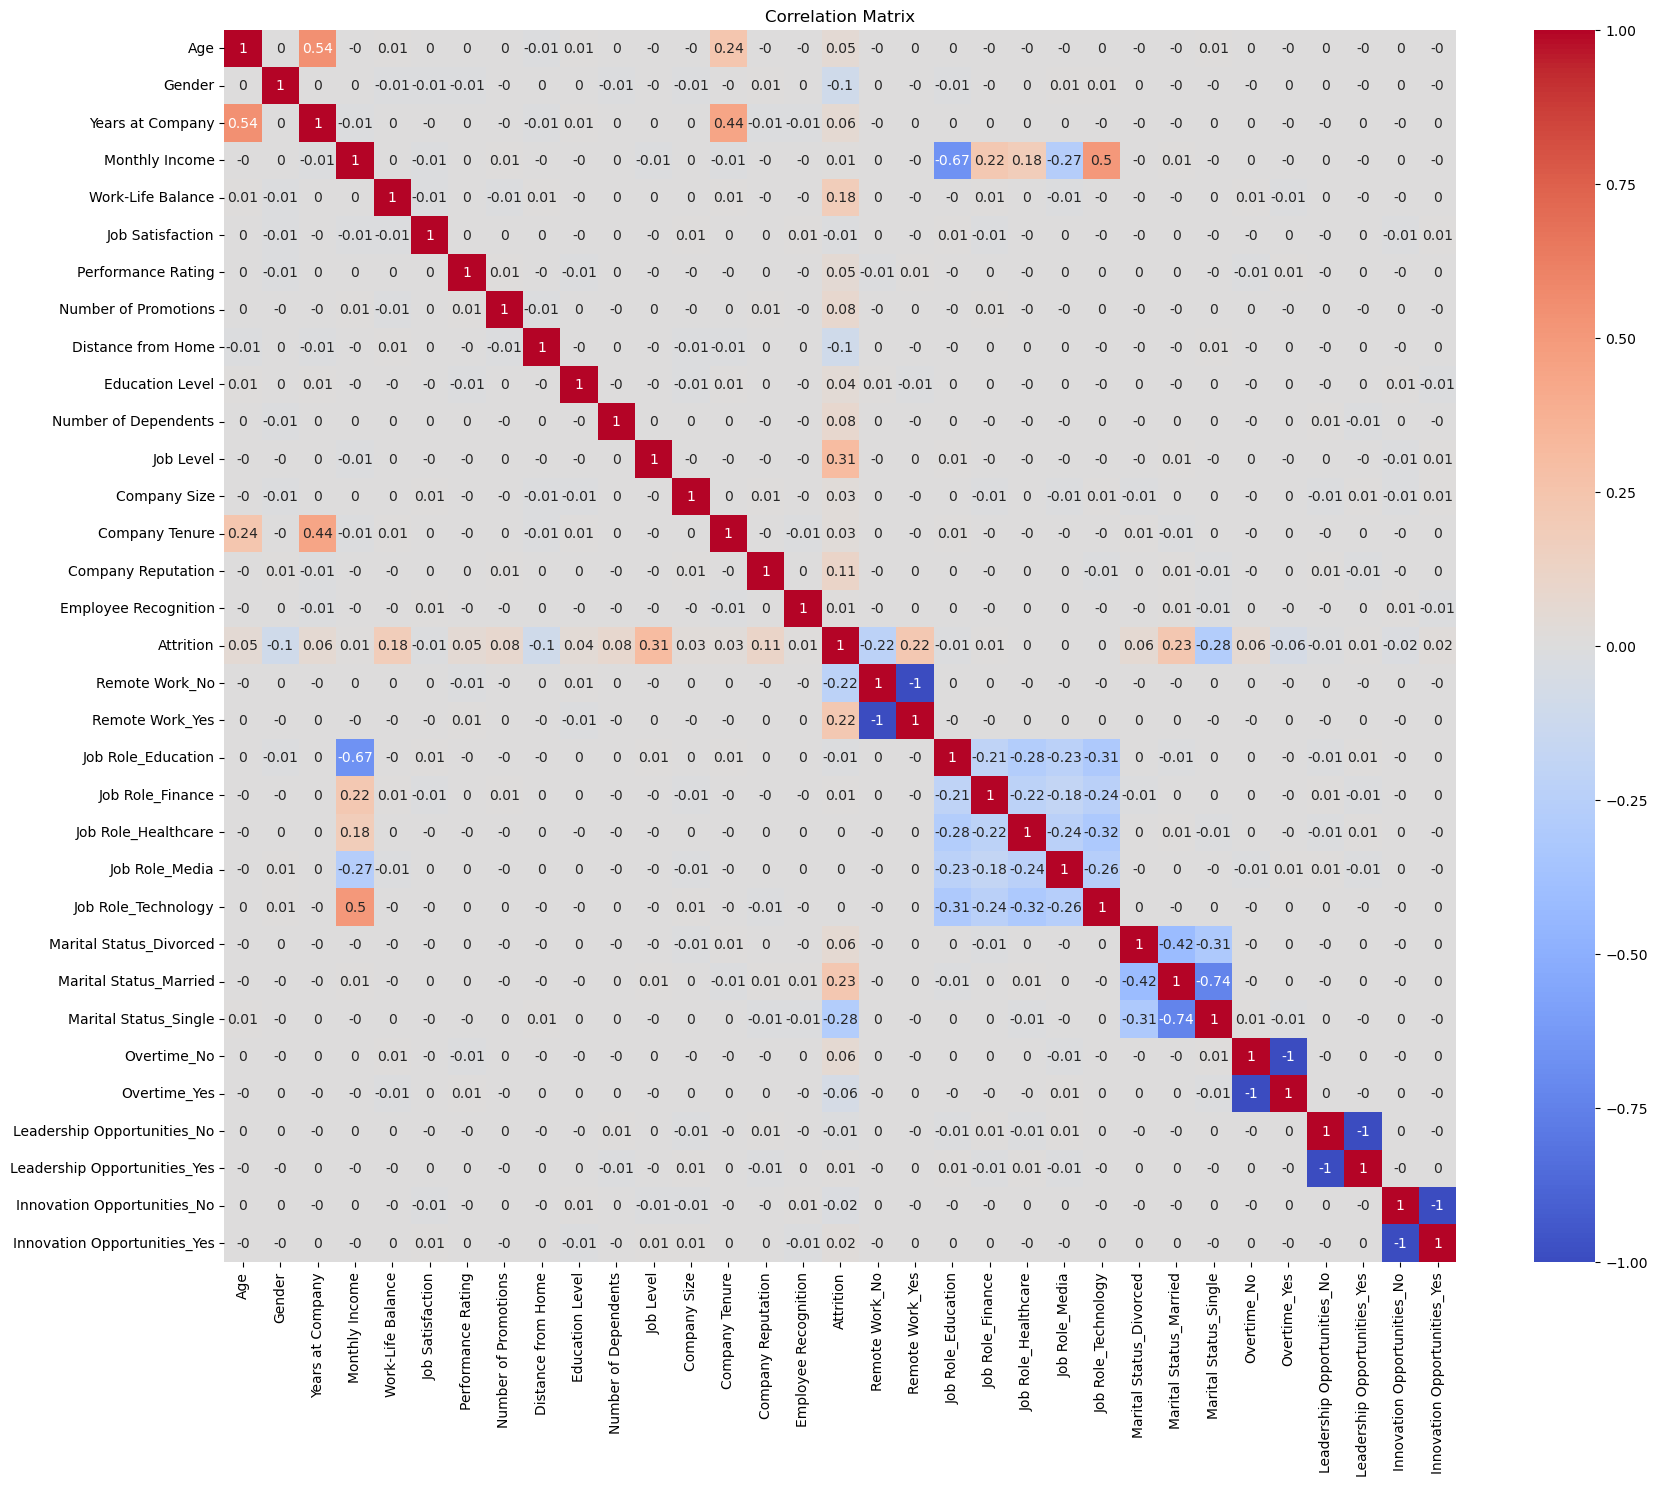

In [5]:
import seaborn as sns
correlation = data.corr().round(2)
plt.figure(figsize=(20, 16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

doesn't seems linear, that could explains why data post pca seems to overlap while data post umap don't (doesn't explain the strange shape tho)

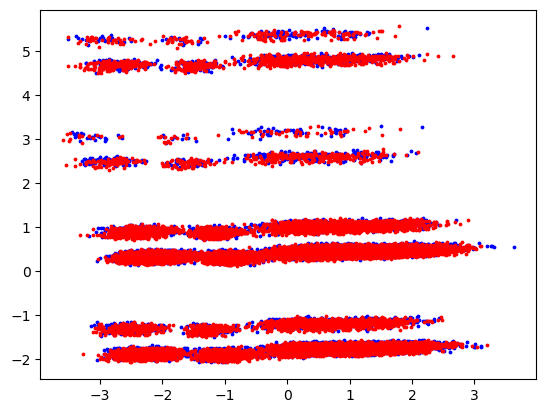

In [6]:
pca = PCA(n_components=2)
X_t= pd.DataFrame(pca.fit_transform(StandardScaler().fit_transform(X)))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

In [7]:
um = umap.UMAP(n_components=2)
X_t = pd.DataFrame(um.fit_transform(StandardScaler().fit_transform(X), y))

plt.scatter(X_t.loc[y==0,0], X_t.loc[y==0,1], c='blue', s=3)
plt.scatter(X_t.loc[y==1,0], X_t.loc[y==1,1], c='red', s=3)
plt.show()

KeyboardInterrupt: 

explained variance of (0,1): 4.083307706127081


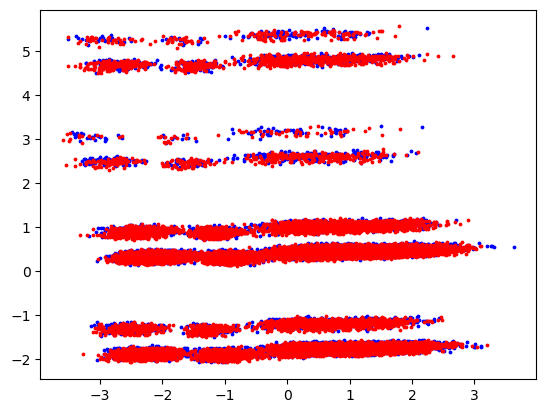

explained variance of (2,3): 4.002191440775798


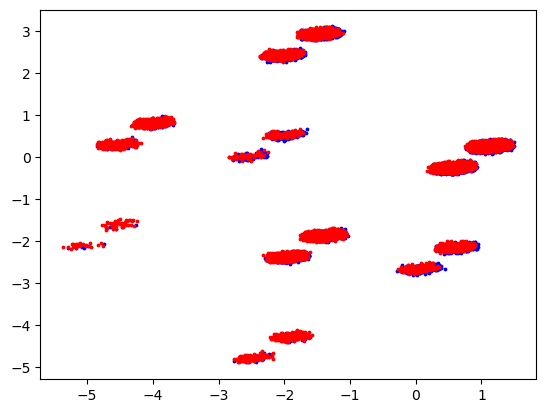

explained variance of (4,5): 3.8202374335240505


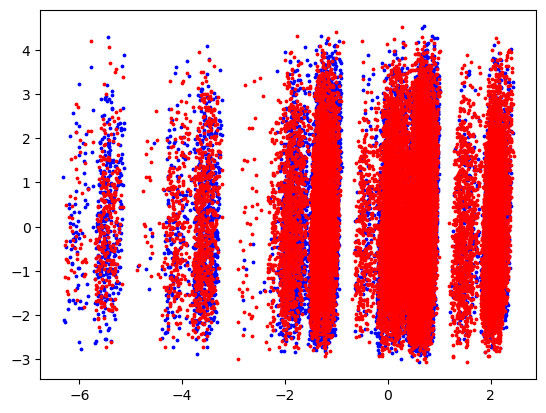

In [7]:
pca = PCA(n_components=6)
X_t = pca.fit_transform(StandardScaler().fit_transform(X))
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    print(f'explained variance of ({i},{i+1}): {pca.explained_variance_[i] + pca.explained_variance_[i+1]}')
    plt.show()

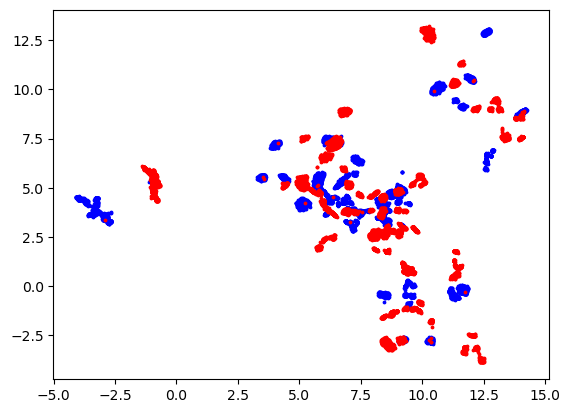

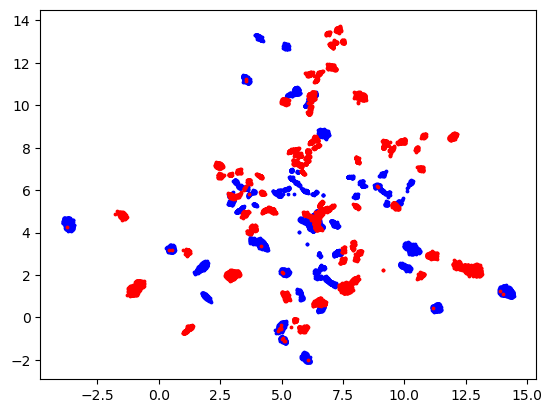

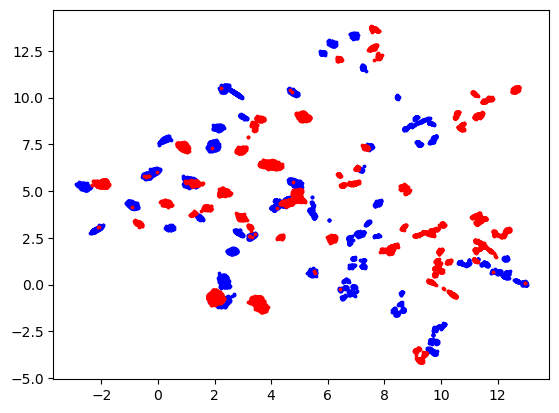

In [8]:

umap1 = umap.UMAP(n_components=6)
X_t = umap1.fit_transform(StandardScaler().fit_transform(X), y)
for i in range(0, 6, 2):
    plt.scatter(X_t[y==0,i], X_t[y==0,i+1], c='blue', s=3)
    plt.scatter(X_t[y==1,i], X_t[y==1,i+1], c='red', s=3)
    plt.show()

In [8]:
from sklearn.model_selection import KFold
X_train, X_valid, Y_train, Y_valid= train_test_split(X, y, test_size=0.2, shuffle=True, random_state=420960)
X_train = X_train.values.astype('float32') if isinstance(X_train, pd.DataFrame) else np.array(X_train, dtype='float32')
Y_train = Y_train.values.astype('float32') if isinstance(Y_train, pd.Series) else np.array(Y_train, dtype='float32')
X_valid = X_valid.values.astype('float32') if isinstance(X_valid, pd.DataFrame) else np.array(X_valid, dtype='float32')
Y_valid = Y_valid.values.astype('float32') if isinstance(Y_valid, pd.Series) else np.array(Y_valid, dtype='float32')

def print_metrics(arr):
  df = pd.DataFrame((['train', arr[0, 0], arr[0, 1]], ['valid',arr[1, 0], arr[1, 1]]), columns=['set', 'accuracy', 'precision']) 
  display(df)

def calc_metrics(X_train, X_valid, y_train, y_valid, model):
  train_pred = model.predict(X_train)
  valid_pred = model.predict(X_valid)
  acc_train= accuracy_score(y_train, train_pred)
  acc_valid= accuracy_score(y_valid, valid_pred)
  prec_train= precision_score(y_train, train_pred)
  prec_valid= precision_score(y_valid, valid_pred)

  arr = [[acc_train, prec_train], [acc_valid, prec_valid]]
  return arr


def kfold(X, Y, model, splits, dim_reduction=None):
  kf = KFold(splits, random_state=420, shuffle=True)
  metrics = np.zeros((2, 2))
  for train_indices, valid_indices in kf.split(X, Y):

    X_train, X_valid, Y_train, Y_valid = [X.iloc[train_indices], X.iloc[valid_indices], Y[train_indices], Y[valid_indices]]

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_valid = sc.transform(X_valid)

    if dim_reduction != None:
      X_train = dim_reduction.fit_transform(X_train)
      X_valid = dim_reduction.transform(X_valid)
      
    model.fit(X_train, Y_train)
    metrics += calc_metrics(X_train, X_valid, Y_train, Y_valid, model)

  metrics /= splits   
  print(model, end="") 
  display(pd.DataFrame([['train', metrics[0,0], metrics[0,1]], ['validation', metrics[1,0], metrics[1,1]]], columns=['set', 'accuracy', 'precision']))
  return model


In [9]:
# finding optimal value for k
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# param_grid = {'knn__n_neighbors': np.arange(21, (int)(np.sqrt(X.shape[0])), 2)}
# knn = KNeighborsClassifier()
# pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('knn', knn)])

# grid_search = GridSearchCV(pipe, param_grid, refit='precision', cv=4, n_jobs=-1, scoring=('accuracy', 'precision'))

# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) 
k = 231
k_t = 231

In [10]:
# for log reg
# param_grid = {'lr__C': np.logspace(-4, 4, base=2)}
# log_reg = LogisticRegression()
# pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('lr', log_reg)])
# grid_search = GridSearchCV(pipe, param_grid, cv=4, n_jobs=-1, scoring=('accuracy', 'precision'), refit='precision')
# grid_search.fit(X_train, Y_train)
# print(grid_search.best_params_) # 0.07837463407059186
# C = C_t = 0.08776538868572868
C = C_t = 100

In [11]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [13]:
def get_model():
    model = Sequential()
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=16, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', 
                    loss='binary_crossentropy', 
                    metrics=['accuracy', 'Precision'])
    return model

def get_model_t():
    model = Sequential()
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', 
                    loss='binary_crossentropy', 
                    metrics=['accuracy', 'Precision'])
    return model

#### pre dimensionality reduction, no pen

In [14]:
folds = [4, 5, 6]

In [23]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, KNeighborsClassifier(n_neighbors=k), i)
  kfold(X, y, LogisticRegression(max_iter=1000, penalty=None), i)

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

,set,accuracy,precision
0,train,0.728526,0.731427
1,validation,0.722189,0.725456


LogisticRegression(max_iter=1000, penalty=None)

,set,accuracy,precision
0,train,0.740411,0.749615
1,validation,0.740025,0.749168


------------------------------------5 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

...

,set,accuracy,precision
0,train,0.740138,0.749302
1,validation,0.739874,0.748900


------------------------------------6 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

,set,accuracy,precision
0,train,0.728048,0.730768
1,validation,0.722877,0.725707


LogisticRegression(max_iter=1000, penalty=None)

,set,accuracy,precision
0,train,0.740253,0.749402
1,validation,0.739689,0.748845


##### post pca dimensionality reduction, no pen

In [24]:
for i in folds:
  print(f'------------------------------------{i} folds------------------------------------')
  kfold(X, y, KNeighborsClassifier(n_neighbors=k), i, PCA())
  kfold(X, y, LogisticRegression(max_iter=1000, penalty=None), i, PCA())

------------------------------------4 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

,set,accuracy,precision
0,train,0.728526,0.731427
1,validation,0.722189,0.725456


LogisticRegression(max_iter=1000, penalty=None)

,set,accuracy,precision
0,train,0.740411,0.749615
1,validation,0.740025,0.749168


------------------------------------5 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

...

,set,accuracy,precision
0,train,0.740105,0.749262
1,validation,0.739874,0.748884


------------------------------------6 folds------------------------------------
KNeighborsClassifier(n_neighbors=231)

,set,accuracy,precision
0,train,0.728048,0.730768
1,validation,0.722877,0.725707


LogisticRegression(max_iter=1000, penalty=None)

,set,accuracy,precision
0,train,0.740253,0.749402
1,validation,0.739689,0.748845


In [15]:
# kfold with keras model
for fold in folds:
    kf = KFold(n_splits=fold, shuffle=True, random_state=42)
    print(f'------------------------------------{fold} folds------------------------------------')
    for train_indices, val_indices in kf.split(X):
        
        # Tách dữ liệu và chuyển đổi thành kiểu số thực (float)
        X_train, X_val = X.iloc[train_indices].values.astype(int), X.iloc[val_indices].values.astype(int)
        y_train, y_val = y.iloc[train_indices].values.astype(int), y.iloc[val_indices].values.astype(int)

        sc = StandardScaler()
        X_train = sc.fit_transform(X_train)
        X_val = sc.transform(X_val)

        # Create and train the model
        model = get_model_t()
        history = model.fit(X_train, y_train, 
                            epochs=20, 
                            batch_size=32, 
                            validation_data=(X_val, y_val),

                            verbose=0)

        # Training and validation metrics
        train_loss, train_acc, train_precision = model.evaluate(X_train, y_train, verbose=0)
        val_loss, val_acc, val_precision = model.evaluate(X_val, y_val, verbose=0)

        print(f"Train Accuracy: {train_acc:.4f}, Train Precision: {train_precision:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}, Validation Precision: {val_precision:.4f}")

------------------------------------4 folds------------------------------------
Train Accuracy: 0.7499, Train Precision: 0.7751
Validation Accuracy: 0.7426, Validation Precision: 0.7656
Train Accuracy: 0.7494, Train Precision: 0.7770
Validation Accuracy: 0.7428, Validation Precision: 0.7714
Train Accuracy: 0.7452, Train Precision: 0.7978
Validation Accuracy: 0.7408, Validation Precision: 0.7987
Train Accuracy: 0.7488, Train Precision: 0.7871
Validation Accuracy: 0.7437, Validation Precision: 0.7760
------------------------------------5 folds------------------------------------
Train Accuracy: 0.7520, Train Precision: 0.7821
Validation Accuracy: 0.7411, Validation Precision: 0.7718
Train Accuracy: 0.7498, Train Precision: 0.7517
Validation Accuracy: 0.7433, Validation Precision: 0.7431
Train Accuracy: 0.7388, Train Precision: 0.8017
Validation Accuracy: 0.7427, Validation Precision: 0.8088
Train Accuracy: 0.7384, Train Precision: 0.8160
Validation Accuracy: 0.7397, Validation Precision:

In [26]:
for fold in folds:
    kf = KFold(n_splits=fold, shuffle=True, random_state=42)
    print(f'------------------------------------{fold} folds------------------------------------')
    for train_indices, val_indices in kf.split(X):
        
        # Tách dữ liệu và chuyển đổi thành kiểu số thực (float)
        X_train, X_val = X.iloc[train_indices].values.astype(int), X.iloc[val_indices].values.astype(int)
        y_train, y_val = y.iloc[train_indices].values.astype(int), y.iloc[val_indices].values.astype(int)

        sc = StandardScaler()
        X_train = sc.fit_transform(X_train)
        X_val = sc.transform(X_val)
        pca = PCA()
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)

        # Create and train the model
        model = get_model_t()
        history = model.fit(X_train, y_train, 
                            epochs=20, 
                            batch_size=32, 
                            validation_data=(X_val, y_val), 
                            verbose=0)

        # Training and validation metrics
        train_loss, train_acc, train_precision = model.evaluate(X_train, y_train, verbose=0)
        val_loss, val_acc, val_precision = model.evaluate(X_val, y_val, verbose=0)

        print(f"Train Accuracy: {train_acc:.4f}, Train Precision: {train_precision:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}, Validation Precision: {val_precision:.4f}")

------------------------------------4 folds------------------------------------
Train Accuracy: 0.7504, Train Precision: 0.7781
Validation Accuracy: 0.7436, Validation Precision: 0.7699
Train Accuracy: 0.7487, Train Precision: 0.7466
Validation Accuracy: 0.7459, Validation Precision: 0.7451
Train Accuracy: 0.7483, Train Precision: 0.7577
Validation Accuracy: 0.7537, Validation Precision: 0.7696
Train Accuracy: 0.7501, Train Precision: 0.7727
Validation Accuracy: 0.7447, Validation Precision: 0.7615
------------------------------------5 folds------------------------------------
Train Accuracy: 0.7518, Train Precision: 0.7469
Validation Accuracy: 0.7419, Validation Precision: 0.7384
Train Accuracy: 0.7418, Train Precision: 0.8060
Validation Accuracy: 0.7378, Validation Precision: 0.7982
Train Accuracy: 0.7444, Train Precision: 0.8014
Validation Accuracy: 0.7429, Validation Precision: 0.8007
Train Accuracy: 0.7421, Train Precision: 0.8166
Validation Accuracy: 0.7384, Validation Precision:

### model visualization and selection

373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step
knn roc curve:


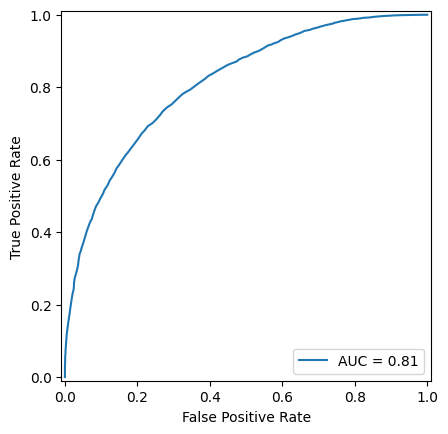

lr roc curve:


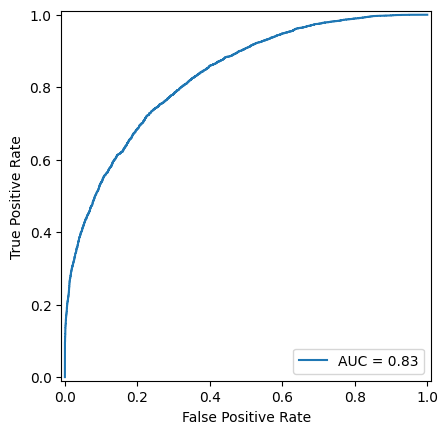

ann roc curve:


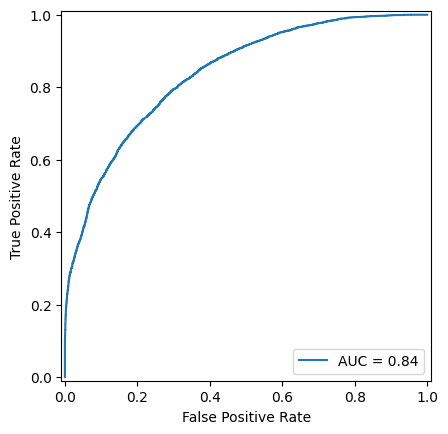

In [48]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
X_train, X_valid, Y_train, Y_valid = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=420)

# pca = PCA()
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_valid = sc.transform(X_valid)
X_train = pca.fit_transform(X_train)
X_valid = pca.transform(X_valid)

knn = KNeighborsClassifier(n_neighbors=k_t)
knn.fit(X_train, Y_train)
lr = LogisticRegression(max_iter=1000, C=C_t)
lr.fit(X_train, Y_train)
ann = get_model_t()
ann.fit(X_train, Y_train, epochs=20, 
                            batch_size=32, 
                            validation_data=(X_valid, Y_valid), 
                            verbose=0)

knn_pred_proba = knn.predict_proba(X_valid)
lr_pred_proba = lr.predict_proba(X_valid)
ann_pred_proba = ann.predict(X_valid)

print("knn roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, knn_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("lr roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, lr_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()


print("ann roc curve:")
fpr, tpr, _ = roc_curve(Y_valid, ann_pred_proba)
roc_auc = auc(fpr, tpr)

roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()
plt.show()

373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step
knn:
0.7307885906040269 0.7362687941086222


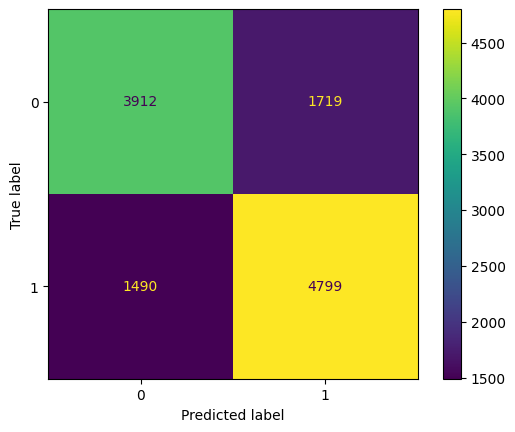

lr:
0.7441275167785235 0.75532082610752


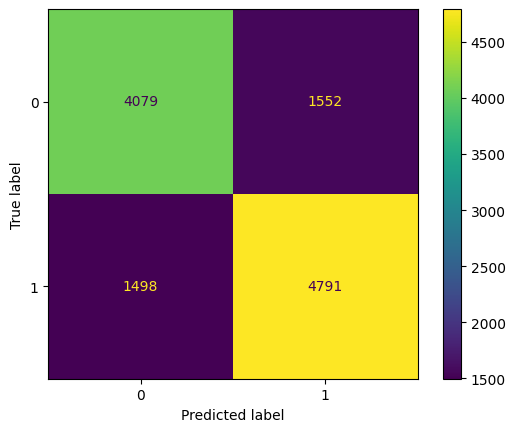

ann:
0.7488255033557047 0.7629688747007183


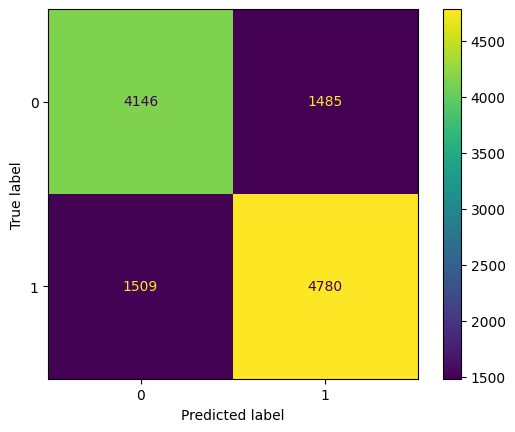

In [49]:
knn_pred = knn.predict(X_valid)
lr_pred = lr.predict(X_valid)
ann_pred = (ann.predict(X_valid) >= 0.5) * 1

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score

print("knn:")
acc = accuracy_score(Y_valid, knn_pred)
prec = precision_score(Y_valid, knn_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("lr:")
acc = accuracy_score(Y_valid, lr_pred)
prec = precision_score(Y_valid, lr_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print("ann:")
acc = accuracy_score(Y_valid, ann_pred)
prec = precision_score(Y_valid, ann_pred)
print(acc, prec)

cm = confusion_matrix(Y_valid, ann_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [50]:
X_test = pd.read_csv('./data/test_processed.csv')
y_test = X_test['Attrition']
X_test = np.array(X_test.drop('Attrition', axis=1))
X_test = sc.transform(X_test)
X_test = pca.transform(X_test)

# Evaluate the model
results = ann.evaluate(X_test, y_test)
print("Test accuracy:", results[1])
print("Test precision:", results[2])

125/466 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - Precision: 0.7591 - accuracy: 0.7519 - loss: 0.5663

/home/minad/ML_final_project/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - Precision: 0.7612 - accuracy: 0.7490 - loss: 0.5646
Test accuracy: 0.7493288516998291
Test precision: 0.7630808353424072
